# Notebook 2: Detailed Data Preprocessing & Feature Engineering

## 1. Introduction

In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Feature selection
from sklearn.feature_selection import mutual_info_regression, SelectKBest

# For transforming skewed features
from scipy import stats

# Configurations
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load the dataset
df = pd.read_csv('house.csv')

# Quick inspection
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")  # Excluding SalePrice
df.head()

Dataset shape: (1460, 81)
Number of features: 80


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Data Splitting

In [3]:
# Separate features and target
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1022, 79)
Testing set shape: (438, 79)


## 3. Handling Missing Values

From our previous EDA, we know that several features contain missing values. Let's develop a comprehensive strategy for handling them.

In [4]:
# Calculate missing values and percentages
missing_values = X_train.isnull().sum()
missing_percent = (missing_values / len(X_train)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)

print(f"Features with missing values: {len(missing_df)}")
missing_df

Features with missing values: 19


,Missing Values,Percentage
PoolQC,1017,99.51
MiscFeature,982,96.09
Alley,956,93.54
Fence,820,80.23
MasVnrType,590,57.73
FireplaceQu,487,47.65
LotFrontage,190,18.59
GarageType,54,5.28
GarageYrBlt,54,5.28
GarageFinish,54,5.28


### 3.2 Imputation Strategies by Feature Type

Let's first categorize our features to apply the right imputation strategy:

In [5]:
# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 36
Categorical features: 43


#### 3.2.1 Handling Missing Categorical Values

For categorical variables, we'll take a more nuanced approach:

In [8]:
# Features where NA means "No Feature"
no_feature_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature'
]

# Replace missing values with "None" for these columns
for col in no_feature_cols:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

In [9]:
# For other categorical columns, fill with the most frequent value (mode)
for col in categorical_cols:
    if col not in no_feature_cols and X_train[col].isnull().sum() > 0:
        most_frequent = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(most_frequent)
        X_test[col] = X_test[col].fillna(most_frequent)

#### 3.2.2 Handling Missing Numerical Values

For numerical features, we'll use different strategies:

In [10]:
# Features where 0 means "No Feature"
zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea', 'GarageCars']

# Fill with 0
for col in zero_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

In [11]:
# For LotFrontage, we'll use median value of the neighborhood
X_train['LotFrontage'] = X_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
# Handle cases where an entire neighborhood is missing LotFrontage in the training set
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(X_train['LotFrontage'].median())

# Apply the same logic to test set, but use training set neighborhoods
for neighborhood in X_test['Neighborhood'].unique():
    median_value = X_train[X_train['Neighborhood'] == neighborhood]['LotFrontage'].median()
    X_test.loc[X_test['Neighborhood'] == neighborhood, 'LotFrontage'] = \
        X_test.loc[X_test['Neighborhood'] == neighborhood, 'LotFrontage'].fillna(median_value)
# Fill any remaining missing values with the overall median
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(X_train['LotFrontage'].median())

In [12]:
# For GarageYrBlt, use YearBuilt when missing (assuming garage built with house)
X_train.loc[X_train['GarageYrBlt'].isnull(), 'GarageYrBlt'] = X_train.loc[X_train['GarageYrBlt'].isnull(), 'YearBuilt']
X_test.loc[X_test['GarageYrBlt'].isnull(), 'GarageYrBlt'] = X_test.loc[X_test['GarageYrBlt'].isnull(), 'YearBuilt']

In [13]:
# Fill any remaining numerical columns with median
for col in numerical_cols:
    if col not in zero_cols and col != 'LotFrontage' and col != 'GarageYrBlt' and X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)


### 3.3 Checking for Remaining Missing Values


In [14]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0


## 4. Handling Categorical Variables

Now that we've addressed missing values, we need to convert categorical variables into a numerical format that our models can understand.


### 4.1 Analyzing Categorical Features

Let's first examine our categorical features to understand their cardinality (number of unique categories):

In [15]:
# Check cardinality of categorical features
cat_cardinality = {col: X_train[col].nunique() for col in categorical_cols}
cat_cardinality_df = pd.DataFrame.from_dict(cat_cardinality, orient='index', columns=['Unique Values'])
cat_cardinality_df = cat_cardinality_df.sort_values('Unique Values', ascending=False)
cat_cardinality_df

,Unique Values
Neighborhood,25
Exterior2nd,16
Exterior1st,14
SaleType,9
Condition1,9
HouseStyle,8
BsmtFinType1,7
RoofMatl,7
BsmtFinType2,7
Functional,7


### 4.2 Encoding Strategies

#### 4.2.1 Ordinal Encoding

For features with a clear order (quality ratings, etc.), we'll use ordinal encoding:

In [16]:
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
135,20,RL,80.0,10400,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,None,MnPrv,None,0,5,2008,WD,Normal
1452,180,RM,35.0,3675,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,None,None,None,0,5,2006,WD,Normal
762,60,FV,72.0,8640,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,None,None,None,0,6,2010,Con,Normal
932,20,RL,84.0,11670,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,None,None,None,0,3,2007,WD,Normal
435,60,RL,43.0,10667,Pave,None,IR2,Lvl,AllPub,CulDSac,...,0,0,None,None,None,0,4,2009,ConLw,Normal


In [17]:
# Define ordinal mappings
quality_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
basement_exposure_mapping = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
basement_finish_mapping = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
fence_mapping = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
garage_finish_mapping = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
lot_shape_mapping = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
functional_mapping = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}

# Apply ordinal mappings
ordinal_features = {
    'ExterQual': quality_mapping,
    'ExterCond': quality_mapping,
    'BsmtQual': quality_mapping,
    'BsmtCond': quality_mapping,
    'BsmtExposure': basement_exposure_mapping,
    'BsmtFinType1': basement_finish_mapping,
    'BsmtFinType2': basement_finish_mapping,
    'HeatingQC': quality_mapping,
    'KitchenQual': quality_mapping,
    'FireplaceQu': quality_mapping,
    'GarageQual': quality_mapping,
    'GarageCond': quality_mapping,
    'GarageFinish': garage_finish_mapping,
    'PoolQC': quality_mapping,
    'Fence': fence_mapping,
    'LotShape': lot_shape_mapping,
    'Functional': functional_mapping,
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'CentralAir': {'N': 0, 'Y': 1}
}

# Apply ordinal mappings to both training and test sets
for feature, mapping in ordinal_features.items():
    X_train[feature] = X_train[feature].map(mapping)
    X_test[feature] = X_test[feature].map(mapping)

In [18]:
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
135,20,RL,80.0,10400,Pave,None,3,Lvl,AllPub,Inside,...,0,0,0,3,None,0,5,2008,WD,Normal
1452,180,RM,35.0,3675,Pave,None,3,Lvl,AllPub,Inside,...,0,0,0,0,None,0,5,2006,WD,Normal
762,60,FV,72.0,8640,Pave,None,3,Lvl,AllPub,Inside,...,0,0,0,0,None,0,6,2010,Con,Normal
932,20,RL,84.0,11670,Pave,None,2,Lvl,AllPub,Corner,...,0,0,0,0,None,0,3,2007,WD,Normal
435,60,RL,43.0,10667,Pave,None,1,Lvl,AllPub,CulDSac,...,0,0,0,0,None,0,4,2009,ConLw,Normal


In [19]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0



#### 4.2.2 One-Hot Encoding

For nominal variables (no inherent order), we'll use one-hot encoding:


In [20]:
# Identify features for one-hot encoding (nominal variables with relatively low cardinality)
nominal_features = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood',
    'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical',
    'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition','Utilities', 'LandSlope'
]

# Check which nominal features exist in our dataset
nominal_features = [f for f in nominal_features if f in X_train.columns]

# Apply one-hot encoding
for feature in nominal_features:
    # Get dummies and drop the first category to avoid multicollinearity
    dummies_train = pd.get_dummies(X_train[feature], prefix=feature, drop_first=True)
    dummies_test = pd.get_dummies(X_test[feature], prefix=feature, drop_first=True)
    
    # Ensure the same columns in test and train
    for col in dummies_train.columns:
        if col not in dummies_test.columns:
            dummies_test[col] = 0
    for col in dummies_test.columns:
        if col not in dummies_train.columns:
            dummies_train[col] = 0
    
    # Add dummy columns to the datasets
    X_train = pd.concat([X_train, dummies_train], axis=1)
    X_test = pd.concat([X_test, dummies_test], axis=1)
    
    # Drop the original column
    X_train = X_train.drop(feature, axis=1)
    X_test = X_test.drop(feature, axis=1)


**Check current shape of our data after one-hot encoding:**


In [21]:
print(f"New training set shape: {X_train.shape}")
print(f"New testing set shape: {X_test.shape}")

New training set shape: (1022, 202)
New testing set shape: (438, 202)


In [22]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0


## 5. Feature Engineering


Feature engineering is the process of creating new features from existing ones, based on domain knowledge or mathematical transformations. This can often significantly improve model performance.




### 5.1 Creating New Features

Let's create several new features that might help predict house prices:

In [23]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Utilities_NoSeWa,LandSlope_Mod,LandSlope_Sev
135,20,80.0,10400,3,7,6,1970,1970,288.0,3,...,False,True,False,False,False,True,False,False,False,False
1452,180,35.0,3675,3,5,5,2005,2005,80.0,3,...,False,True,False,False,False,True,False,False,False,False
762,60,72.0,8640,3,7,5,2009,2009,0.0,3,...,False,False,False,False,False,True,False,False,False,False
932,20,84.0,11670,2,9,5,2006,2006,302.0,5,...,False,True,False,False,False,True,False,False,False,False
435,60,43.0,10667,1,7,6,1996,1996,0.0,4,...,False,False,False,False,False,True,False,False,False,False


In [24]:
# 1. Total Square Footage
X_train['TotalSF'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']
X_test['TotalSF'] = X_test['TotalBsmtSF'] + X_test['1stFlrSF'] + X_test['2ndFlrSF']

# 2. Total Bathrooms
X_train['TotalBathrooms'] = X_train['FullBath'] + (0.5 * X_train['HalfBath']) + \
                             X_train['BsmtFullBath'] + (0.5 * X_train['BsmtHalfBath'])
X_test['TotalBathrooms'] = X_test['FullBath'] + (0.5 * X_test['HalfBath']) + \
                            X_test['BsmtFullBath'] + (0.5 * X_test['BsmtHalfBath'])

# 3. House Age (at time of sale)
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

# 4. Years Since Remodel (at time of sale)
X_train['RemodAge'] = X_train['YrSold'] - X_train['YearRemodAdd']
X_test['RemodAge'] = X_test['YrSold'] - X_test['YearRemodAdd']

# 5. Has Pool
X_train['HasPool'] = (X_train['PoolArea'] > 0).astype(int)
X_test['HasPool'] = (X_test['PoolArea'] > 0).astype(int)

# 6. Has Garage
X_train['HasGarage'] = (X_train['GarageArea'] > 0).astype(int)
X_test['HasGarage'] = (X_test['GarageArea'] > 0).astype(int)

# 7. Has Fireplace
X_train['HasFireplace'] = (X_train['Fireplaces'] > 0).astype(int)
X_test['HasFireplace'] = (X_test['Fireplaces'] > 0).astype(int)

# 8. Total Porch Area
X_train['TotalPorchSF'] = X_train['OpenPorchSF'] + X_train['EnclosedPorch'] + \
                           X_train['3SsnPorch'] + X_train['ScreenPorch']
X_test['TotalPorchSF'] = X_test['OpenPorchSF'] + X_test['EnclosedPorch'] + \
                          X_test['3SsnPorch'] + X_test['ScreenPorch']
# 9. Remodeled (binary)
X_train['Remodeled'] = (X_train['YearBuilt'] != X_train['YearRemodAdd']).astype(int)
X_test['Remodeled'] = (X_test['YearBuilt'] != X_test['YearRemodAdd']).astype(int)

# 10. TotalQual - a combination of OverallQual and OverallCond
X_train['TotalQual'] = X_train['OverallQual'] * X_train['OverallCond']
X_test['TotalQual'] = X_test['OverallQual'] * X_test['OverallCond']

In [25]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,TotalSF,TotalBathrooms,HouseAge,RemodAge,HasPool,HasGarage,HasFireplace,TotalPorchSF,Remodeled,TotalQual
135,20,80.0,10400,3,7,6,1970,1970,288.0,3,...,2986,2.0,38,38,0,1,1,0,0,42
1452,180,35.0,3675,3,5,5,2005,2005,80.0,3,...,1619,2.0,1,1,0,1,0,28,0,25
762,60,72.0,8640,3,7,5,2009,2009,0.0,3,...,2303,2.5,1,1,0,1,0,45,0,35
932,20,84.0,11670,2,9,5,2006,2006,302.0,5,...,3810,2.0,1,1,0,1,1,191,0,45
435,60,43.0,10667,1,7,6,1996,1996,0.0,4,...,2460,3.5,13,13,0,1,1,61,0,42


In [26]:
# Columns to DROP after feature engineering
cols_to_drop = [
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',  # Replaced by TotalSF
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', # Replaced by TotalBathrooms
    'YearBuilt', 'YearRemodAdd', # Replaced by Age features
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', # Replaced by TotalPorchSF
    'PoolArea', # Replaced by HasPool
    # 'GarageArea' -> DO NOT DROP (HasGarage is too weak to replace it)
    # 'Fireplaces' -> DO NOT DROP (Count is better than Binary)
    # 'OverallQual' -> DO NOT DROP (It is the King of features)
]

# Safe to drop command
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [27]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,TotalSF,TotalBathrooms,HouseAge,RemodAge,HasPool,HasGarage,HasFireplace,TotalPorchSF,Remodeled,TotalQual
135,20,80.0,10400,3,7,6,288.0,3,3,3,...,2986,2.0,38,38,0,1,1,0,0,42
1452,180,35.0,3675,3,5,5,80.0,3,3,4,...,1619,2.0,1,1,0,1,0,28,0,25
762,60,72.0,8640,3,7,5,0.0,3,3,4,...,2303,2.5,1,1,0,1,0,45,0,35
932,20,84.0,11670,2,9,5,302.0,5,3,5,...,3810,2.0,1,1,0,1,1,191,0,45
435,60,43.0,10667,1,7,6,0.0,4,3,4,...,2460,3.5,13,13,0,1,1,61,0,42


In [28]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0


## 6. Numerical Feature Transformation

### 6.1 Handling Skewed Features



Many numerical features in real estate data follow skewed distributions. Let's identify and transform these features:

In [29]:
# Identify skewed numerical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
skewed_features = []
skewness_values = {}

for feature in numeric_features:
    skewness = X_train[feature].skew()
    if abs(skewness) > 0.75:  # Threshold for determining high skewness
        skewed_features.append(feature)
        skewness_values[feature] = skewness

# Sort skewness values
skewness_df = pd.DataFrame({
    'Feature': skewed_features,
    'Skewness': [skewness_values[f] for f in skewed_features]
})
skewness_df = skewness_df.sort_values('Skewness', ascending=False)

print(f"Number of skewed numerical features: {len(skewed_features)}")
skewness_df.head(10)
# Show top skewed features and visualize skewness distribution
print(f"Number of skewed numerical features: {len(skewed_features)}\n")
display(skewness_df.head(10))

Number of skewed numerical features: 28
Number of skewed numerical features: 28



,Feature,Skewness
25,MiscVal,16.792815
23,PoolQC,15.398347
2,LotArea,11.649804
15,LowQualFinSF,9.100801
12,BsmtFinSF2,4.350905
17,KitchenAbvGr,4.083854
11,BsmtFinType2,3.375745
1,LotFrontage,2.613409
4,MasVnrArea,2.218286
27,TotalPorchSF,2.141732


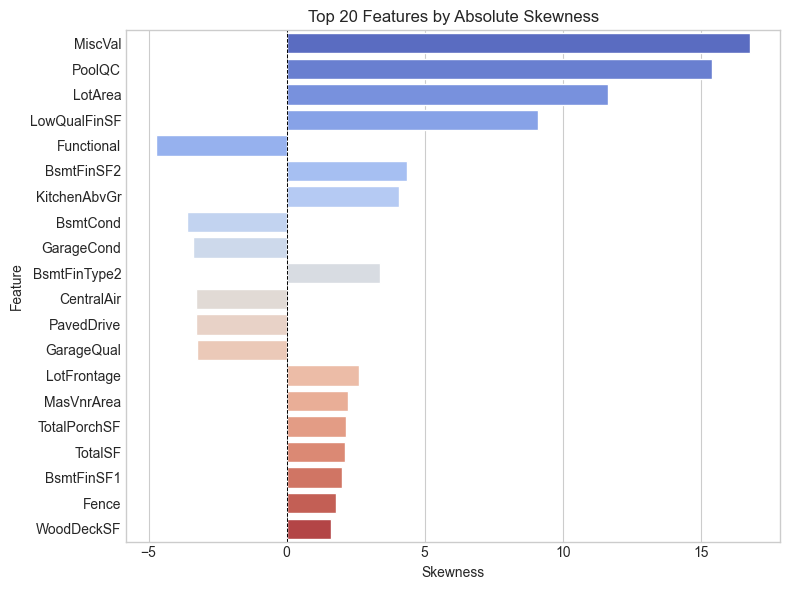

In [30]:
# Bar plot of skewness (top 20 by absolute skew)
skew_plot_df = skewness_df.reindex(skewness_df['Skewness'].abs().sort_values(ascending=False).index).head(20)
plt.figure(figsize=(8,6))
sns.barplot(x='Skewness', y='Feature', data=skew_plot_df, palette='coolwarm')
plt.axvline(0, color='k', linestyle='--', linewidth=0.7)
plt.title('Top 20 Features by Absolute Skewness')
plt.tight_layout()
plt.show()

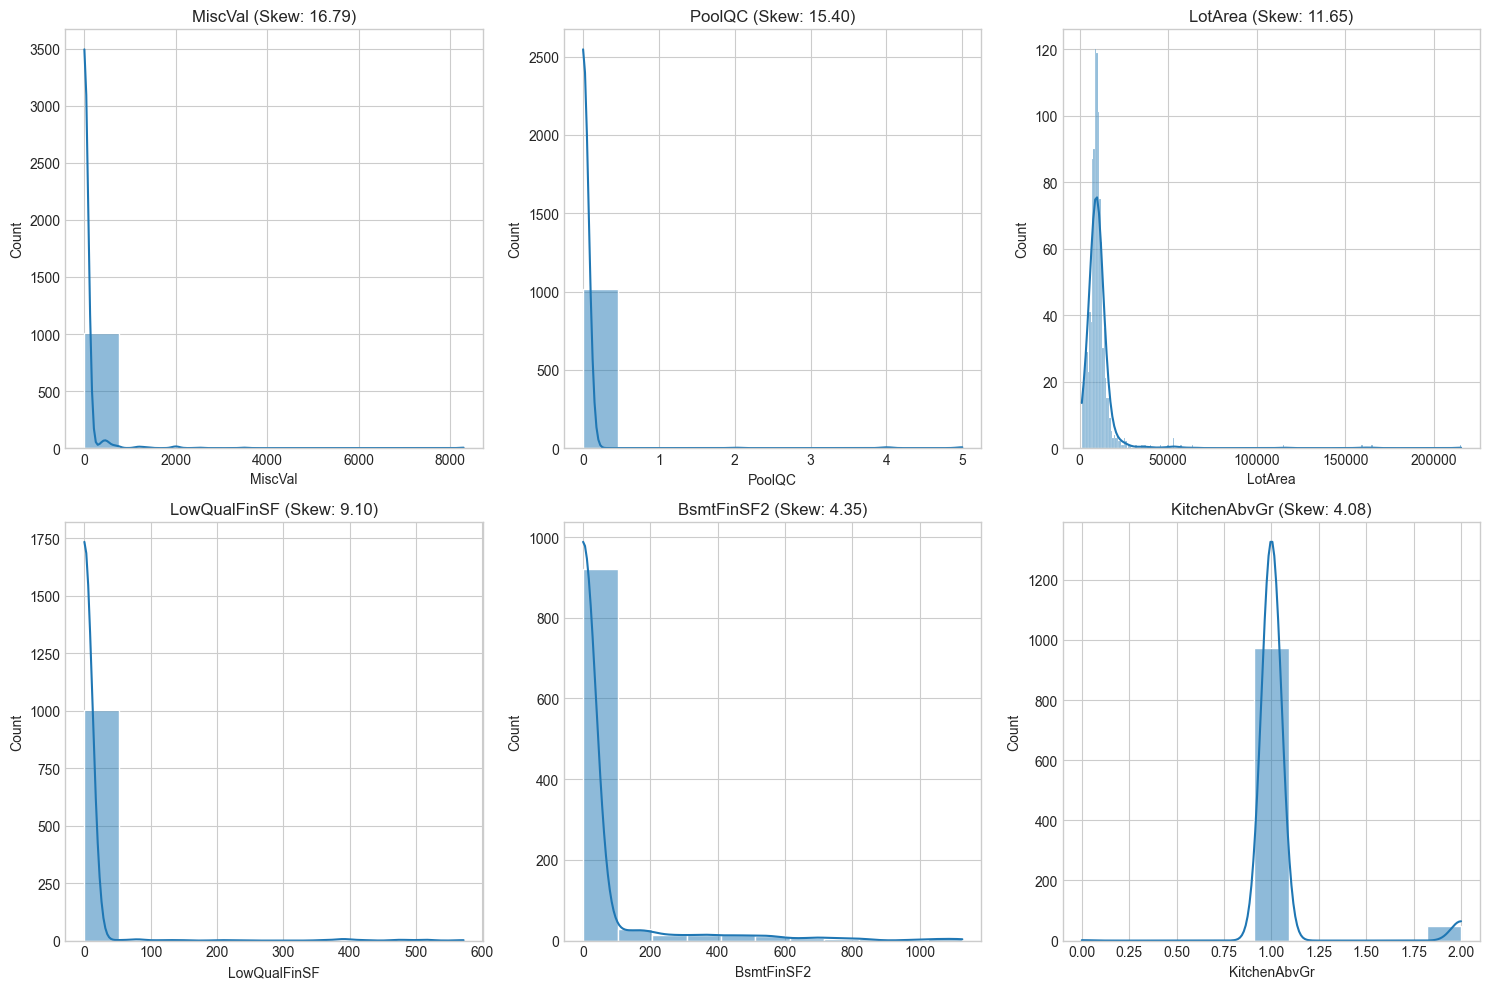

In [31]:
# Visualize some highly skewed features before transformation
plt.figure(figsize=(15, 10))
for i, feature in enumerate(skewness_df['Feature'].head(6)):
    plt.subplot(2, 3, i+1)
    sns.histplot(X_train[feature], kde=True)
    plt.title(f'{feature} (Skew: {X_train[feature].skew():.2f})')
    plt.tight_layout()
plt.show()


Now, let's apply log transformation to the highly skewed features:


In [32]:
from sklearn.preprocessing import PowerTransformer

# method='yeo-johnson' works for positive AND negative values
pt = PowerTransformer(method='yeo-johnson')

# It automatically handles the skew (positive or negative)
X_train[skewed_features] = pt.fit_transform(X_train[skewed_features])
X_test[skewed_features] = pt.transform(X_test[skewed_features])

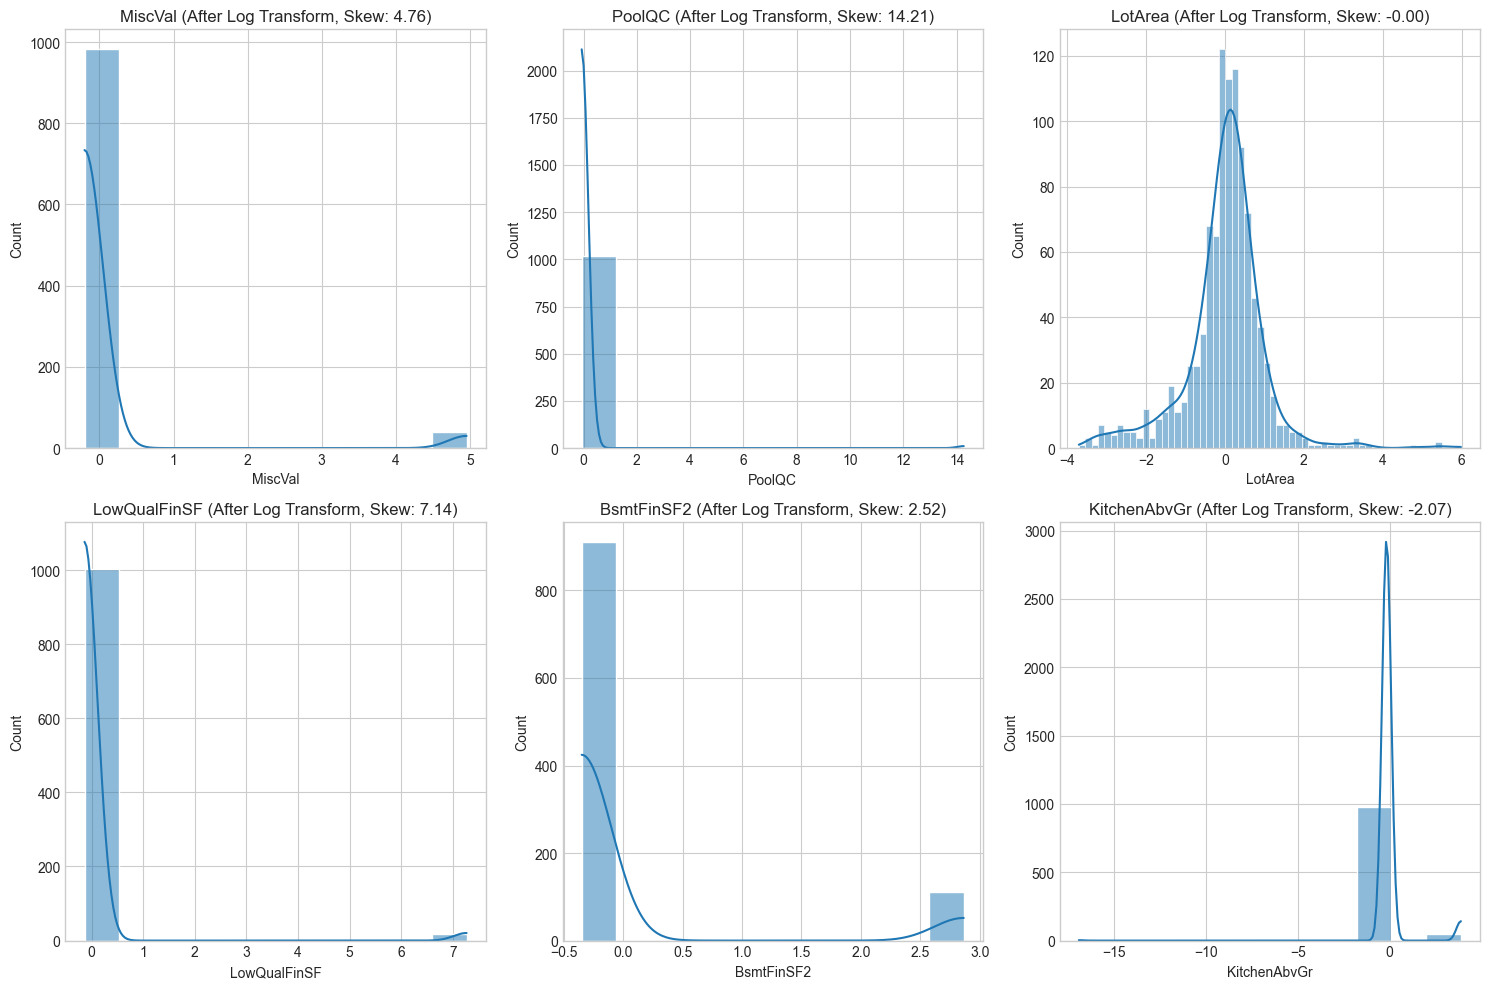

In [33]:
# Visualize the same features after transformation
plt.figure(figsize=(15, 10))
for i, feature in enumerate(skewness_df['Feature'].head(6)):
    plt.subplot(2, 3, i+1)
    sns.histplot(X_train[feature], kde=True)
    plt.title(f'{feature} (After Log Transform, Skew: {X_train[feature].skew():.2f})')
    plt.tight_layout()
plt.show()

In [34]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0


### 6.2 Feature Scaling

In [35]:
# Standardize numerical features
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [36]:
# Verify that all missing values have been handled
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0



## 7. Feature Selection

With all our preprocessing and feature engineering, we now have many features. Let's select the most relevant ones using mutual information:


In [37]:
# Use mutual information to select top features
# First, normalize the target (log transformation makes more sense for price data)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_train, y_train_log)
mi_scores = pd.Series(mi_scores, index=X_train.columns)
mi_scores = mi_scores.sort_values(ascending=False)

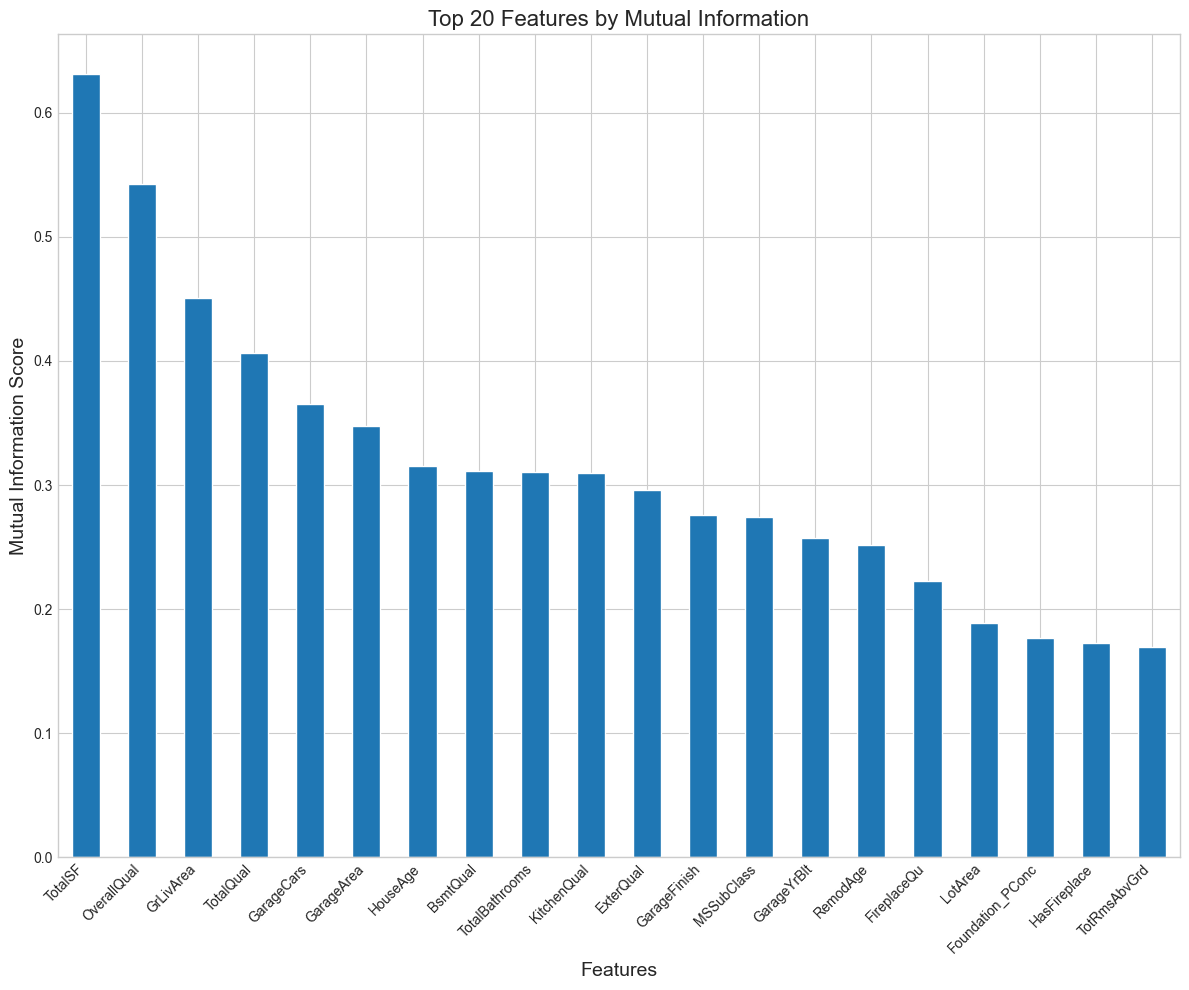

In [38]:
# Display top 20 features by mutual information
plt.figure(figsize=(12, 10))
mi_scores[:20].plot.bar()
plt.title('Top 20 Features by Mutual Information', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Mutual Information Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
print("Top 20 features by mutual information:")
print(mi_scores[:20])

Top 20 features by mutual information:
TotalSF             0.631642
OverallQual         0.542823
GrLivArea           0.450383
TotalQual           0.406161
GarageCars          0.365669
GarageArea          0.348006
HouseAge            0.315551
BsmtQual            0.311509
TotalBathrooms      0.310170
KitchenQual         0.309550
ExterQual           0.295870
GarageFinish        0.275540
MSSubClass          0.274014
GarageYrBlt         0.257150
RemodAge            0.252067
FireplaceQu         0.222902
LotArea             0.188611
Foundation_PConc    0.176670
HasFireplace        0.172543
TotRmsAbvGrd        0.169793
dtype: float64



Let's use a threshold to select the most important features:


In [40]:
# Select features with MI score above a threshold
threshold = 0.1  # This value can be adjusted
selected_features = mi_scores[mi_scores > threshold].index.tolist()

print(f"Number of selected features: {len(selected_features)}")
print("Selected features:")
print(selected_features)

Number of selected features: 30
Selected features:
['TotalSF', 'OverallQual', 'GrLivArea', 'TotalQual', 'GarageCars', 'GarageArea', 'HouseAge', 'BsmtQual', 'TotalBathrooms', 'KitchenQual', 'ExterQual', 'GarageFinish', 'MSSubClass', 'GarageYrBlt', 'RemodAge', 'FireplaceQu', 'LotArea', 'Foundation_PConc', 'HasFireplace', 'TotRmsAbvGrd', 'Fireplaces', 'HeatingQC', 'LotFrontage', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtUnfSF', 'GarageType_Detchd', 'GarageType_Attchd', 'OverallCond', 'MasVnrArea']


In [41]:
# Prepare final datasets with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"Final training set shape: {X_train_selected.shape}")
print(f"Final testing set shape: {X_test_selected.shape}")

Final training set shape: (1022, 30)
Final testing set shape: (438, 30)


In [42]:
# Verify that all missing values have been handled
train_missing = X_train_selected.isnull().sum().sum()
test_missing = X_test_selected.isnull().sum().sum()

print(f"Missing values in training set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

Missing values in training set: 0
Missing values in test set: 0



## 8. Evaluating the Impact of Preprocessing

Now, let's evaluate how our preprocessing steps improved model performance:


In [41]:
# Train a linear regression model on the processed dataset
processed_model = LinearRegression()
processed_model.fit(X_train_selected, y_train_log)

LinearRegression()

In [43]:

# Make predictions
y_pred_log = processed_model.predict(X_test_selected)


In [44]:
rmse_log_processed = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

# For R2, we typically want to see how well it predicts REAL dollars
# So we inverse transform (expm1) the predictions back to dollar amounts
y_pred_dollars = np.expm1(y_pred_log)
r2_processed = r2_score(y_test, y_pred_dollars)

print(f"RMSE on log scale (processed features): {rmse_log_processed:.4f}")
print(f"R² (processed features): {r2_processed:.4f}")
# Compare with the baseline model from Notebook 1

RMSE on log scale (processed features): 0.1343
R² (processed features): 0.8895


In [45]:
rmse_lg_dollars = np.sqrt(mean_squared_error(y_test, y_pred_dollars))
rmse_lg_dollars

27766.282589838705

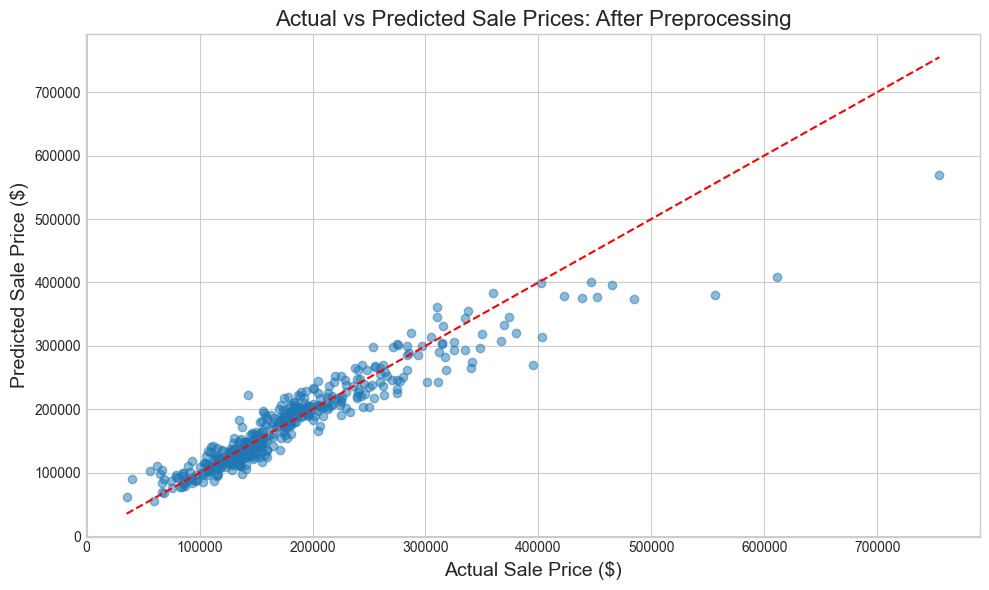

In [46]:
# Visualize actual vs predicted prices with our processed model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dollars, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price ($)', fontsize=14)
plt.ylabel('Predicted Sale Price ($)', fontsize=14)
plt.title('Actual vs Predicted Sale Prices: After Preprocessing', fontsize=16)
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show();

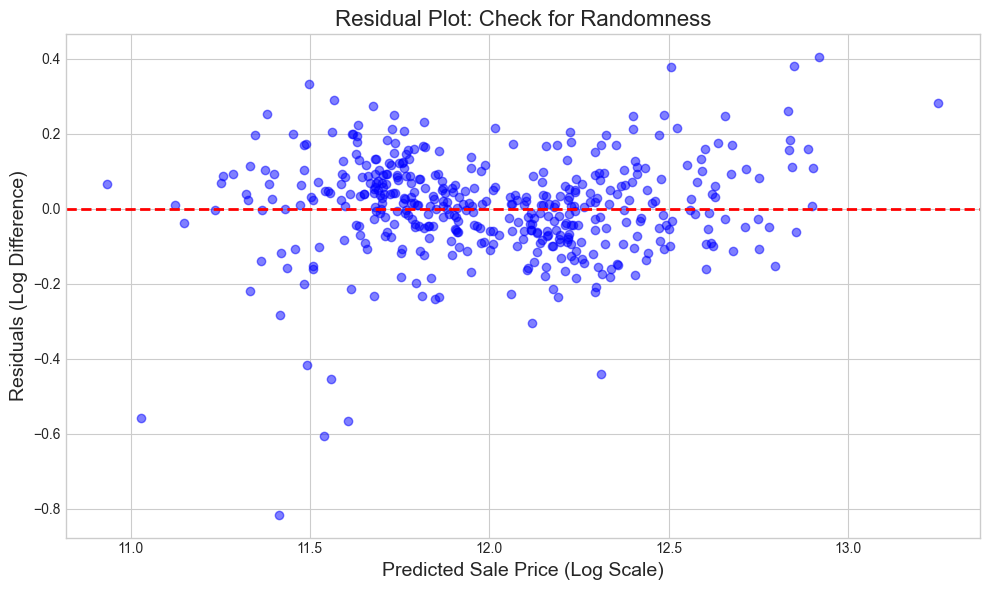

In [47]:
import matplotlib.pyplot as plt

# 1. Calculate residuals (Actual Log Price - Predicted Log Price)
residuals_log = y_test_log - y_pred_log

# 2. Plot Predicted vs. Residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_log, residuals_log, alpha=0.5, color='blue')

# 3. Add a horizontal line at 0 (Perfect prediction line)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

# 4. Formatting
plt.xlabel('Predicted Sale Price (Log Scale)', fontsize=14)
plt.ylabel('Residuals (Log Difference)', fontsize=14)
plt.title('Residual Plot: Check for Randomness', fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Train SVR
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # RBF kernel for non-linearity
svr_model.fit(X_train_selected, y_train_log)

# Predict
y_pred_svr = svr_model.predict(X_test_selected)
y_pred_svr_dollars = np.expm1(y_pred_svr)

# Evaluate
rmse_svr_log = np.sqrt(mean_squared_error(y_test_log, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr_dollars)

# RMSE in dollars (back-transform)
#y_test_dollars = np.expm1(y_test)
rmse_svr_dollars = np.sqrt(mean_squared_error(y_test, y_pred_svr_dollars))

print(f"SVR - RMSE (Log Scale): {rmse_svr_log:.4f}")
print(f"SVR - R² Score: {r2_svr:.4f}")
print(f"SVR - RMSE (Dollars): ${rmse_svr_dollars:.2f}")

SVR - RMSE (Log Scale): 0.1334
SVR - R² Score: 0.8960
SVR - RMSE (Dollars): $26940.13


In [54]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train Decision Tree
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)  # Limited depth to reduce overfitting
dt_model.fit(X_train_selected, y_train_log)

# Predict
y_pred_dt = dt_model.predict(X_test_selected)
y_pred_dt_dollars = np.expm1(y_pred_dt)

# Evaluate
rmse_dt_log = np.sqrt(mean_squared_error(y_test_log, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt_dollars)

# RMSE in dollars
#y_pred_dt_dollars = np.expm1(y_pred_dt)
rmse_dt_dollars = np.sqrt(mean_squared_error(y_test, y_pred_dt_dollars))

print(f"Decision Tree - RMSE (Log Scale): {rmse_dt_log:.4f}")
print(f"Decision Tree - R² Score: {r2_dt:.4f}")
print(f"Decision Tree - RMSE (Dollars): ${rmse_dt_dollars:.2f}")

Decision Tree - RMSE (Log Scale): 0.1904
Decision Tree - R² Score: 0.8319
Decision Tree - RMSE (Dollars): $34250.34


In [55]:
import pandas as pd

# Metrics from original Linear Regression (from Section 8)
lr_metrics = {
    "Model": "Linear Regression",
    "RMSE (Log Scale)": rmse_log_processed,
    "R2 Score": r2_processed,
    "RMSE (Dollars)": rmse_lg_dollars
}

# Metrics from above models (replace with actual printed values if running live)
svr_metrics = {
    "Model": "Support Vector Machine (SVR)",
    "RMSE (Log Scale)": rmse_svr_log,  # From SVR code output
    "R2 Score": r2_svr,
    "RMSE (Dollars)": rmse_svr_dollars
}

dt_metrics = {
    "Model": "Decision Tree Regressor",
    "RMSE (Log Scale)": rmse_dt_log,  # From DT code output
    "R2 Score": r2_dt,
    "RMSE (Dollars)": rmse_dt_dollars
}

# Create DataFrame
comparison_df = pd.DataFrame([lr_metrics, svr_metrics, dt_metrics])
print(comparison_df)

                          Model  RMSE (Log Scale)  R2 Score  RMSE (Dollars)
0             Linear Regression          0.134302  0.889516    27766.282590
1  Support Vector Machine (SVR)          0.133444  0.895993    26940.130360
2       Decision Tree Regressor          0.190433  0.831890    34250.336032
